### Настройки стиля

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

mpl.rcParams["font.family"]       = "DejaVu Sans"
mpl.rcParams["axes.spines.top"]   = False
mpl.rcParams["axes.spines.right"] = False

BLUE   = "#1F4E79"
LIGHT  = "#AED6F1"
ACCENT = "#E74C3C"

# Человекочитаемые названия колонок для подписей на графиках
labels = {
    "area":  "Площадь (кв. м)",
    "metro": "Удалённость от метро (мин)",
    "price": "Цена сделки (млн руб.)",
}
cols = ["area", "metro", "price"]

### Загрузка csv и предобработка

In [ ]:
df = pd.read_csv(
    "/content/dataset.csv",
    sep=",",
    decimal=",",        # запятая как десятичный разделитель
    thousands=None,
    encoding="utf-8",
)

# Переименуем колонки для удобства работы
df.columns = ["ID", "area", "metro", "price"]

# Убедимся, что типы числовые
df[["area", "metro", "price"]] = df[["area", "metro", "price"]].apply(pd.to_numeric)

print(df.dtypes)
print(df.head(5))
print(f"\nФорма датасета: {df.shape}")

ID         int64
area     float64
metro    float64
price    float64
dtype: object
   ID  area  metro  price
0   1  63.9    5.0  10.78
1   2  52.5    3.0  10.72
2   3  66.7    2.0  11.13
3   4  82.4    4.0  15.24
4   5  50.8   29.0   7.78

Форма датасета: (100, 4)


### Гистограммы

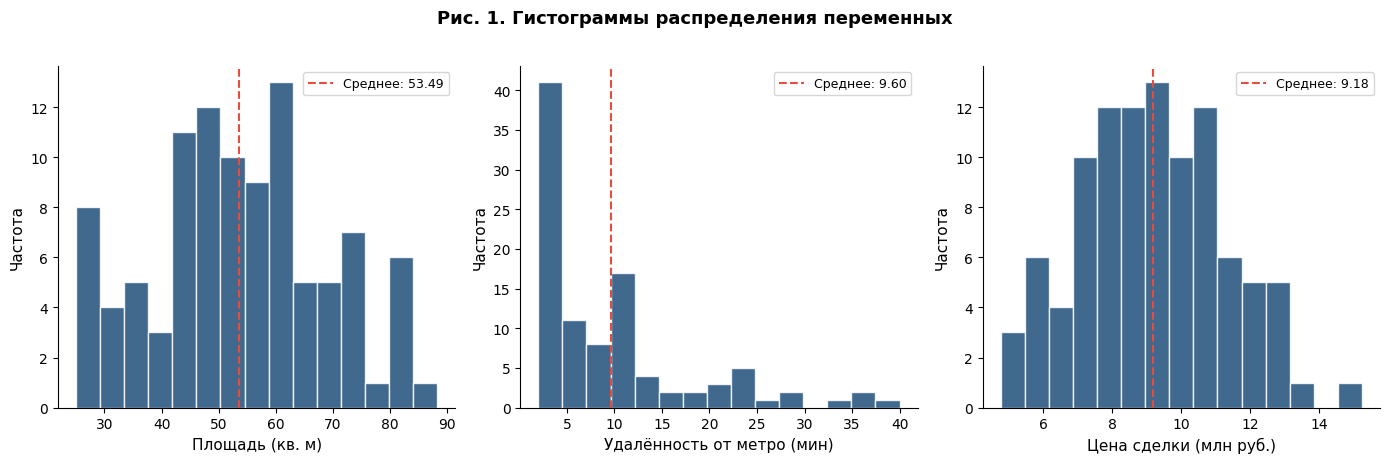

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Рис. 1. Гистограммы распределения переменных",
             fontsize=13, fontweight="bold", y=1.02)

for ax, col in zip(axes, cols):
    ax.hist(df[col], bins=15, color=BLUE, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color=ACCENT, linestyle="--", linewidth=1.5,
               label=f"Среднее: {df[col].mean():.2f}")
    ax.set_xlabel(labels[col], fontsize=11)
    ax.set_ylabel("Частота", fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("hist.png", dpi=150, bbox_inches="tight")
plt.show()

### Box-plot (ящичковые диаграммы)

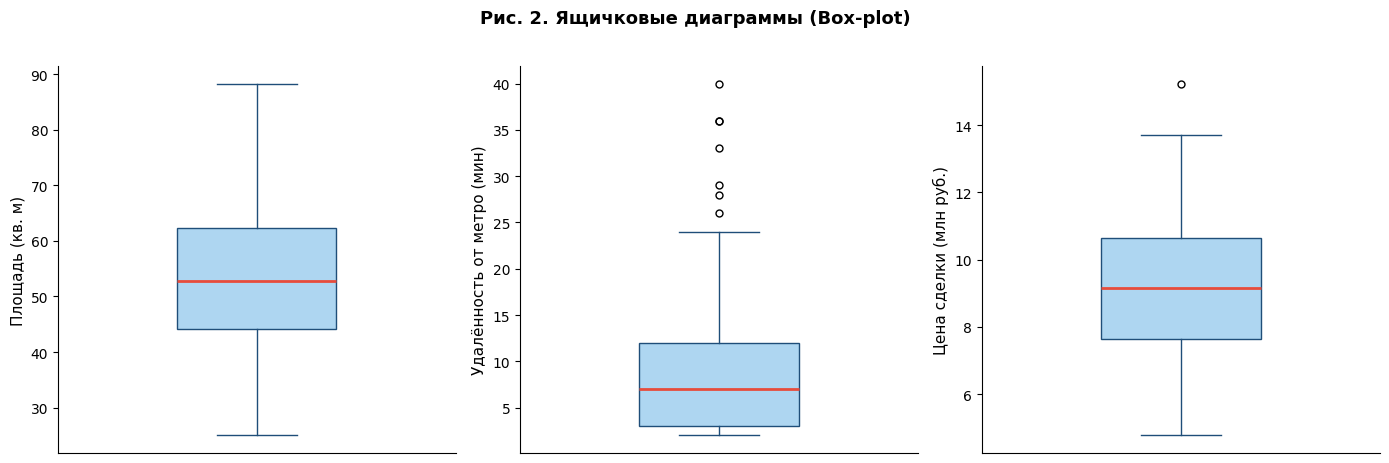

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Рис. 2. Ящичковые диаграммы (Box-plot)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, col in zip(axes, cols):
    ax.boxplot(df[col], patch_artist=True, widths=0.4,
               boxprops=dict(facecolor=LIGHT, color=BLUE),
               medianprops=dict(color=ACCENT, linewidth=2),
               whiskerprops=dict(color=BLUE),
               capprops=dict(color=BLUE),
               flierprops=dict(marker="o", color=ACCENT, markersize=5))
    ax.set_ylabel(labels[col], fontsize=11)
    ax.set_xticks([])

plt.tight_layout()
plt.savefig("boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Проверка нормальности

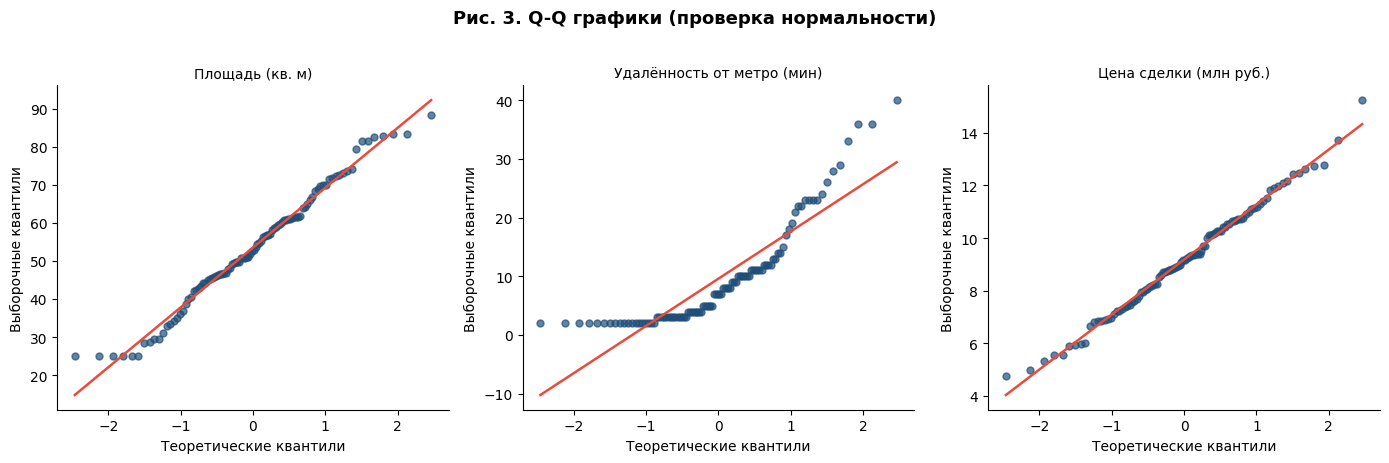

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Рис. 3. Q-Q графики (проверка нормальности)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, col in zip(axes, cols):
    (osm, osr), (slope, intercept, _) = stats.probplot(df[col], dist="norm")
    ax.scatter(osm, osr, color=BLUE, s=25, alpha=0.7)
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope * line_x + intercept, color=ACCENT, linewidth=1.8)
    ax.set_xlabel("Теоретические квантили", fontsize=10)
    ax.set_ylabel("Выборочные квантили", fontsize=10)
    ax.set_title(labels[col], fontsize=10)

plt.tight_layout()
plt.savefig("qq.png", dpi=150, bbox_inches="tight")
plt.show()

### Диаграммы рассеяния

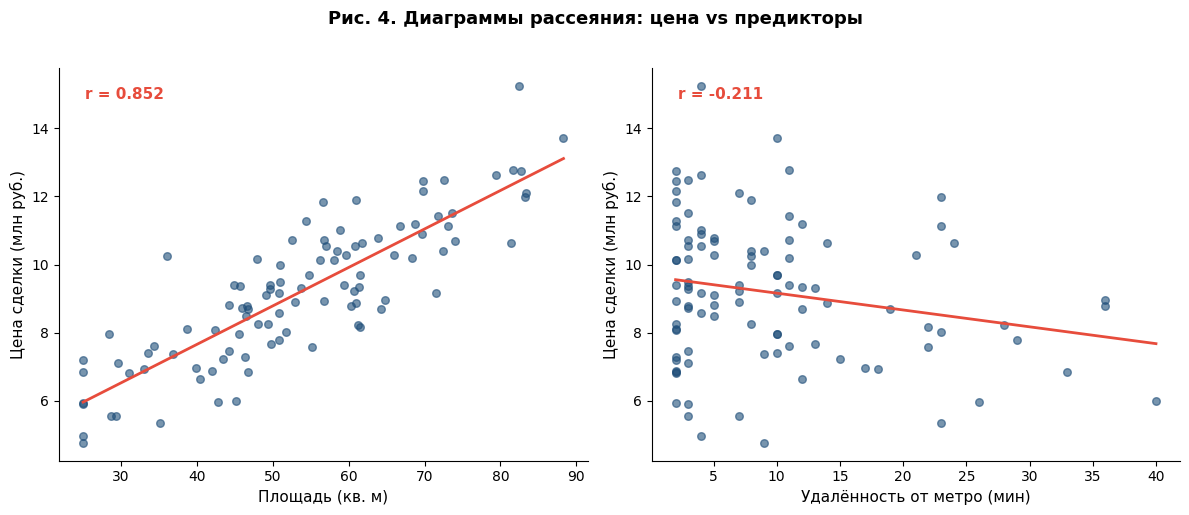

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Рис. 4. Диаграммы рассеяния: цена vs предикторы",
             fontsize=13, fontweight="bold", y=1.02)

predictors = ["area", "metro"]

for ax, col in zip(axes, predictors):
    x = df[col].values
    y = df["price"].values
    r = df[col].corr(df["price"])

    ax.scatter(x, y, color=BLUE, s=30, alpha=0.6)
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color=ACCENT, linewidth=2)
    ax.set_xlabel(labels[col], fontsize=11)
    ax.set_ylabel(labels["price"], fontsize=11)
    ax.text(0.05, 0.92, f"r = {r:.3f}", transform=ax.transAxes,
            fontsize=11, color=ACCENT, fontweight="bold")

plt.tight_layout()
plt.savefig("scatter.png", dpi=150, bbox_inches="tight")
plt.show()

### Тепловая карта корреляций

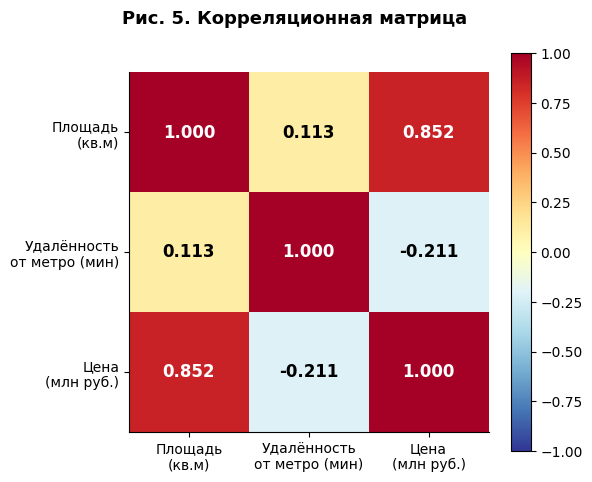

In [ ]:
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
fig.suptitle("Рис. 5. Корреляционная матрица", fontsize=13, fontweight="bold")

im = ax.imshow(corr, cmap="RdYlBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

tick_labels = ["Площадь\n(кв.м)", "Удалённость\nот метро (мин)", "Цена\n(млн руб.)"]
ax.set_xticks(range(3)); ax.set_xticklabels(tick_labels, fontsize=10)
ax.set_yticks(range(3)); ax.set_yticklabels(tick_labels, fontsize=10)

for i in range(3):
    for j in range(3):
        val = corr.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=12, fontweight="bold", color=color)

plt.tight_layout()
plt.savefig("corrmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Составляем модель

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

mpl.rcParams["font.family"]       = "DejaVu Sans"
mpl.rcParams["axes.spines.top"]   = False
mpl.rcParams["axes.spines.right"] = False

BLUE   = "#1F4E79"
LIGHT  = "#AED6F1"
ACCENT = "#E74C3C"

df = pd.read_csv("dataset.csv", sep=",", decimal=",")
df.columns = ["ID", "area", "metro", "price"]
df[["area", "metro", "price"]] = df[["area", "metro", "price"]].apply(pd.to_numeric)

# МНК вручную
n = len(df)
X = np.column_stack([np.ones(n), df["area"].values, df["metro"].values])
y = df["price"].values
XtX_inv = np.linalg.inv(X.T @ X)
beta = XtX_inv @ X.T @ y
y_hat = X @ beta

print(f"β0 = {beta[0]:.4f},  β1 = {beta[1]:.4f},  β2 = {beta[2]:.4f}")

β0 = 3.5949,  β1 = 0.1175,  β2 = -0.0728


### Проверяем модель

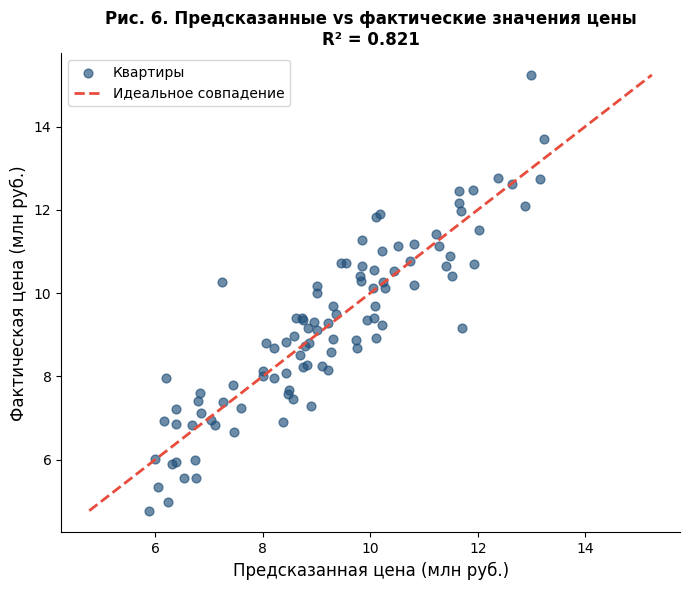

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_hat, y, color=BLUE, s=40, alpha=0.65, label="Квартиры")

# Линия идеального совпадения
mn, mx = min(y_hat.min(), y.min()), max(y_hat.max(), y.max())
ax.plot([mn, mx], [mn, mx], color=ACCENT, linewidth=2,
        linestyle="--", label="Идеальное совпадение")

ax.set_xlabel("Предсказанная цена (млн руб.)", fontsize=12)
ax.set_ylabel("Фактическая цена (млн руб.)", fontsize=12)
ax.set_title("Рис. 6. Предсказанные vs фактические значения цены\n"
             f"R² = 0.821", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### Коэффициенты регрессии

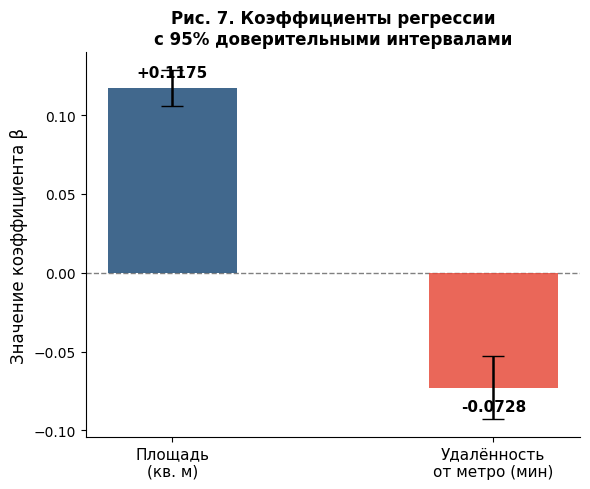

In [ ]:
# Коэффициенты и 95% ДИ (из раздела 4)
coef_names  = ["Площадь\n(кв. м)", "Удалённость\nот метро (мин)"]
coef_values = [0.1175, -0.0728]
ci_low      = [0.1061, -0.0930]
ci_high     = [0.1289, -0.0527]

# Планки погрешностей: расстояние от коэфф. до границы ДИ
err_low  = [v - lo for v, lo in zip(coef_values, ci_low)]
err_high = [hi - v for v, hi in zip(coef_values, ci_high)]

colors = [BLUE if v > 0 else ACCENT for v in coef_values]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(coef_names, coef_values, color=colors, alpha=0.85,
              width=0.4, zorder=3)
ax.errorbar(coef_names, coef_values,
            yerr=[err_low, err_high],
            fmt="none", color="black", capsize=8, linewidth=1.8, zorder=4)

ax.axhline(0, color="gray", linewidth=1, linestyle="--")

# Подписи значений над/под столбцами
for bar, val in zip(bars, coef_values):
    offset = 0.005 if val > 0 else -0.007
    ax.text(bar.get_x() + bar.get_width()/2,
            val + offset, f"{val:+.4f}",
            ha="center", va="bottom" if val > 0 else "top",
            fontsize=11, fontweight="bold")

ax.set_ylabel("Значение коэффициента β", fontsize=12)
ax.set_title("Рис. 7. Коэффициенты регрессии\nс 95% доверительными интервалами",
             fontsize=12, fontweight="bold")
ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.savefig("coef_plot.png", dpi=150, bbox_inches="tight")
plt.show()